# Preprocesamiento de datos para modelado predictivo

En esta fase del proyecto se lleva a cabo la preparación del conjunto de datos con el objetivo de construir un dataset adecuado para el entrenamiento de modelos de aprendizaje automático orientados a la predicción del reingreso hospitalario a 30 días.

A partir de las conclusiones obtenidas en el análisis exploratorio (EDA), se han identificado una serie de retos metodológicos que deben ser abordados en esta etapa, entre los que destacan:

- Presencia de valores ausentes en variables relevantes
- Alta cardinalidad en determinadas variables categóricas
- Desbalanceo en la variable objetivo
- Ausencia de relaciones lineales fuertes entre variables y objetivo
- Necesidad de transformar variables categóricas para su uso en modelos

El objetivo de este notebook es construir un pipeline de preprocesamiento que permita:

- Mejorar la calidad y consistencia de los datos
- Reducir la dimensionalidad innecesaria
- Transformar adecuadamente las variables categóricas
- Generar nuevas variables relevantes (feature engineering)
- Preparar el dataset final para el entrenamiento y evaluación de modelos

Todas las decisiones adoptadas en esta fase están guiadas tanto por criterios estadísticos como por consideraciones metodológicas orientadas a maximizar la capacidad predictiva y la generalización del modelo.

## Importación de librerias y carga de datos


In [111]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [82]:
df = pd.read_csv("../data/raw/diabetic_data.csv")

print(f"Shape: {df.shape}")
df.head()

Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Selección de variables

En esta etapa se seleccionan las variables que serán utilizadas en el modelo, excluyendo aquellas que no aportan valor predictivo o que pueden introducir problemas metodológicos, como identificadores únicos o variables con alta proporción de valores ausentes.

In [83]:
cols_to_drop = ['encounter_id', 'patient_nbr','weight','glyburide-metformin','glipizide-metformin','glimepiride-pioglitazone',
                'metformin-rosiglitazone','metformin-pioglitazone','max_glu_serum','A1Cresult']
df_model = df.drop(columns=cols_to_drop)

In [84]:
df_model.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,Ch,Yes,NO


La selección de variables no se ha basado únicamente en criterios de disponibilidad, sino en una evaluación crítica de su relevancia clínica, calidad de los datos y capacidad de generalización. Se han eliminado variables con alta proporción de valores ausentes, baja frecuencia o carácter identificador, mientras que aquellas relacionadas con la complejidad clínica y el uso de recursos sanitarios han sido priorizadas.


## Tratamiento de valores ausentes

El análisis exploratorio ha mostrado que ciertas variables presentan un alto porcentaje de valores ausentes. En función de su relevancia y proporción de missing, se adoptan distintas estrategias:

- Eliminación de variables con alto porcentaje de valores ausentes
- Imputación en variables relevantes
- Reinterpretación de valores "?" como categoría explícita

In [85]:
df_model = df_model.replace('?', np.nan)

# Imputar categóricas
df_model['payer_code'] = df_model['payer_code'].fillna('Unknown')
df_model['medical_specialty'] = df_model['medical_specialty'].fillna('Unknown')
df_model['diag_1'] = df_model['diag_1'].fillna('NotSpecified')
df_model['diag_2'] = df_model['diag_2'].fillna('NotSpecified')
df_model['diag_3'] = df_model['diag_3'].fillna('NotSpecified')
df_model['race'] = df_model['race'].fillna("Unknown")
missing = df_model.isnull().mean().sort_values(ascending=False)
missing.head(20)

race                        0.0
gender                      0.0
age                         0.0
admission_type_id           0.0
discharge_disposition_id    0.0
admission_source_id         0.0
time_in_hospital            0.0
payer_code                  0.0
medical_specialty           0.0
num_lab_procedures          0.0
num_procedures              0.0
num_medications             0.0
number_outpatient           0.0
number_emergency            0.0
number_inpatient            0.0
diag_1                      0.0
diag_2                      0.0
diag_3                      0.0
number_diagnoses            0.0
metformin                   0.0
dtype: float64

## Definición de la variable objetivo

La variable original `readmitted` se transforma en una variable binaria (`readmit_30`), donde:

- 1: reingreso en menos de 30 días
- 0: resto de casos

Esta transformación permite formular el problema como una tarea de clasificación binaria, en caso que la variable readmitted tenga valor NO, se tomará como 0.

In [86]:
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [87]:
df_model['readmit_30'] = (df['readmitted'] == '<30').astype(int)

df_model['readmit_30'].value_counts(normalize=True)
df_model['readmit_30'].value_counts(normalize=True)

readmit_30
0    0.888401
1    0.111599
Name: proportion, dtype: float64

## Feature Engineering

Se generan nuevas variables derivadas con el objetivo de capturar mejor la complejidad clínica y el uso previo del sistema sanitario.

In [88]:
df_model['total_visits'] = (
    df_model['number_outpatient'] +
    df_model['number_emergency'] +
    df_model['number_inpatient']
) #Numero total de visitas

In [89]:
#Variables severidad de visita
df_model['is_frequent_patient'] = (df_model['number_inpatient'] > 2).astype(int) #frecuencia de hospitalización previa

df_model['severity_index'] = (
    df_model['number_diagnoses'] *
    df_model['time_in_hospital']
)
df_model['care_intensity'] = (
    df_model['num_lab_procedures'] +
    df_model['num_procedures'] +
    df_model['num_medications']
)

In [90]:
#Variables derivadas medicamentos

drug_cols = ['metformin','repaglinide','nateglinide','chlorpropamide','glimepiride','acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone',
             'rosiglitazone','acarbose','miglitol','troglitazone','tolazamide','examide','citoglipton','insulin','diabetesMed']  # lista de medicamentos

df_model['medications_per_day'] = (
    df_model['num_medications'] / df_model['time_in_hospital']
)

df_model['num_diabetes_drugs'] = (df_model[drug_cols] != 'No').sum(axis=1)

df_model['intensive_treatment'] = (
    (df_model['insulin'] != 'No') &
    (df_model['num_diabetes_drugs'] > 1)
).astype(int)

In [91]:
#Variables de diagnósticos
df_model['diabetes_primary'] = df_model['diag_1'].str.startswith('250').astype(int)
df_model['has_chronic'] = df_model[['diag_1','diag_2','diag_3']].apply(
    lambda x: any(str(d).startswith(('250','401','428')) for d in x),
    axis=1
).astype(int)

In [92]:
#Variables administrativas
df_model['emergency_admission'] = (df_model['admission_type_id'] == 1).astype(int)

El proceso de feature engineering se ha orientado a mejorar la representación del problema mediante la construcción de variables derivadas con significado clínico y relevancia predictiva, evitando la generación indiscriminada de nuevas variables.

En particular, se han definido variables que capturan tres dimensiones clave del riesgo de reingreso: (1) la utilización previa del sistema sanitario, mediante indicadores como el número total de visitas o la frecuencia de hospitalización; (2) la complejidad clínica del paciente, aproximada a través del número de diagnósticos y su interacción con la duración de la estancia; y (3) la intensidad del episodio asistencial, reflejada en el volumen de procedimientos, medicación y pruebas realizadas.

Asimismo, se han incorporado variables relacionadas con el tratamiento farmacológico, como el número de fármacos antidiabéticos y la presencia de tratamiento intensivo, así como variables clínicas derivadas de los diagnósticos que permiten identificar la presencia de enfermedades crónicas relevantes.

Durante este proceso, se ha priorizado la interpretabilidad y coherencia clínica de las variables frente a la maximización puramente estadística del rendimiento. En este sentido, se han descartado variables redundantes o con escasa aportación incremental, con el objetivo de evitar sobreajuste y mejorar la capacidad de generalización del modelo.

Este enfoque permite construir un conjunto de variables más informativo y alineado con el contexto clínico del problema, facilitando tanto el rendimiento predictivo como la interpretabilidad de los modelos desarrollados.

## Reducción de cardinalidad en variables categóricas

Algunas variables categóricas presentan un número elevado de categorías, lo que puede afectar negativamente al rendimiento del modelo. Se agrupan categorías poco frecuentes en una categoría común ("Other").

Como vimos en el EDA, las variables que presentan mayor cardinalidad son `encounter_id`,`patient_nbr`,`diag_3`,`diag_2`,`diag_1`. Las dos primeras se eliminaron en apartados anteriores dado que no aportaban nada, el resto vamos a agruparlas usando la clasificación ICD-9

In [93]:
def map_diag(diag):
    diag = str(diag)

    if diag.startswith('250'):
        return 'Diabetes'
    elif diag.startswith(('390','391','392','393','394','395','396','397','398','399')):
        return 'Circulatory'
    elif diag.startswith(('460','461','462','463','464','465','466','467','468','469')):
        return 'Respiratory'
    elif diag.startswith(('520','521','522','523','524','525','526','527','528','529')):
        return 'Digestive'
    else:
        return 'Other'

In [94]:
for col in ['diag_1','diag_2','diag_3']:
    df_model[col + '_group'] = df_model[col].apply(map_diag)

La variable `medical_speciality` cuenta también con 72 categorías, algunas bastante raras, pasaremos a agruparlas por frecuencia

In [95]:
top_specialties = df_model['medical_specialty'].value_counts().nlargest(10).index

df_model['medical_specialty_group'] = df_model['medical_specialty'].apply(
    lambda x: x if x in top_specialties else 'Other'
)

`payer_code` cuenta con 40% de missing values + 17 categorías, seguiremos el mismo criterio que la anterior.

In [96]:
top_payers = df_model['payer_code'].value_counts().nlargest(5).index

df_model['payer_group'] = df_model['payer_code'].apply(
    lambda x: x if x in top_payers else 'Other'
)

Usaremos el csv auxiliar 'IDS_mapping.csv' para agrupar las variables `discharge_disposition_id` y `admission_source_id`, ya que, también cuentan con muchas categorías diferentes algunas raramente usadas.

In [97]:
def map_discharge(x):
    if x in [1]:
        return 'Home'
    elif x in [3,5,6]:
        return 'Care Facility'
    elif x in [2,4]:
        return 'Transfer'
    else:
        return 'Other'

def map_admission_source(x):
    if x in [1,2,3]:
        return 'Referral'
    elif x in [7]:
        return 'Emergency'
    else:
        return 'Other'

In [98]:
df_model['discharge_disposition_group'] = df_model['discharge_disposition_id'].apply(map_discharge)
df_model['admission_source_group'] = df_model['admission_source_id'].apply(map_admission_source)

In [99]:
original_cols = [
    'diag_1', 'diag_2', 'diag_3',
    'medical_specialty',
    'payer_code','discharge_disposition_id',
    'admission_source_id'
]

transformed_cols = [
    'diag_1_group', 'diag_2_group', 'diag_3_group',
    'medical_specialty_group',
    'payer_group','discharge_disposition_group','admission_source_group'
]

cardinality_comparison = pd.DataFrame({
    'Variable': original_cols,
    'Cardinalidad original': [df_model[col].nunique() for col in original_cols],
    'Cardinalidad reducida': [df_model[col].nunique() for col in transformed_cols]
})

# Mostrar tabla
cardinality_comparison

,Variable,Cardinalidad original,Cardinalidad reducida
0,diag_1,717,5
1,diag_2,749,5
2,diag_3,790,5
3,medical_specialty,73,11
4,payer_code,18,6
5,discharge_disposition_id,26,4
6,admission_source_id,17,3


## Codificación de variables categóricas

Las variables categóricas se transforman mediante técnicas de codificación para permitir su uso en modelos de machine learning.

En esta fase exploratoria se emplea one-hot encoding y ordinal encoding para la edad, aunque se considerarán alternativas más avanzadas en la fase de modelado.

In [100]:
#One hot
cat_cols = [
    'race',
    'gender',
    'medical_specialty_group',
    'payer_group',
    'diag_1_group',
    'diag_2_group',
    'diag_3_group'
]
id="n2r4sf"
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

In [101]:
#Edad
id="5z2k1r"
age_mapping = {
    '[0-10)': 0,
    '[10-20)': 1,
    '[20-30)': 2,
    '[30-40)': 3,
    '[40-50)': 4,
    '[50-60)': 5,
    '[60-70)': 6,
    '[70-80)': 7,
    '[80-90)': 8,
    '[90-100)': 9
}

df_model['age'] = df_model['age'].map(age_mapping)

In [102]:
#Variables administrativas
id="9q2fvh"
admin_cols = [
    'admission_type_id',
    'discharge_disposition_group',
    'admission_source_group'
]

df_model = pd.get_dummies(df_model, columns=admin_cols, drop_first=True)

## Conclusiones: Codificación de variables categóricas

La codificación de variables categóricas se ha abordado como una fase crítica dentro del preprocesamiento, dado su impacto directo tanto en el rendimiento de los modelos como en la interpretabilidad de los resultados. En este sentido, no se ha aplicado un enfoque uniforme, sino que la estrategia de codificación se ha adaptado a la naturaleza específica de cada tipo de variable.

En primer lugar, las variables categóricas nominales, que no presentan un orden intrínseco entre sus categorías, han sido transformadas mediante codificación one-hot. Este método permite representar adecuadamente la información categórica sin introducir relaciones artificiales entre categorías, lo cual resulta especialmente relevante en modelos sensibles a la estructura de los datos, como la regresión logística.

En segundo lugar, la variable edad, originalmente representada en forma de intervalos, ha sido tratada como una variable ordinal. Se ha llevado a cabo una transformación a valores numéricos manteniendo el orden natural de los rangos, lo que permite preservar la relación jerárquica entre categorías sin incrementar innecesariamente la dimensionalidad del conjunto de datos.

Asimismo, las variables administrativas codificadas originalmente como identificadores numéricos han sido tratadas explícitamente como variables categóricas, evitando su interpretación errónea como variables continuas. Previamente a su codificación, estas variables han sido sometidas a un proceso de reducción de cardinalidad mediante agrupación de categorías, lo que ha permitido simplificar su estructura, mejorar la estabilidad estadística y facilitar la interpretación de los resultados. Posteriormente, se ha aplicado codificación one-hot sobre dichas variables agrupadas.

Este enfoque escalonado —basado en la reducción de cardinalidad seguida de una codificación adecuada— permite equilibrar la fidelidad en la representación de los datos con la eficiencia computacional y la capacidad de generalización de los modelos. Además, contribuye a minimizar el riesgo de sobreajuste asociado a una alta dimensionalidad y a mejorar la robustez de los modelos en escenarios de validación.

En conjunto, la estrategia de codificación adoptada se fundamenta en criterios metodológicos orientados a preservar el significado de las variables, evitar la introducción de sesgos estructurales y garantizar la coherencia entre la representación de los datos y los requisitos de los algoritmos de aprendizaje automático empleados en el estudio.

## División del dataset

El dataset se divide en conjuntos de entrenamiento y test utilizando una partición estratificada para preservar la distribución de la variable objetivo.

In [103]:
# Separación variables / target
X = df_model.drop('readmit_30', axis=1)
y = df_model['readmit_30']

# División estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Comprobación de shapes
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Comprobación de distribución de la variable objetivo
print("\nDistribución en train:")
print(y_train.value_counts(normalize=True))

print("\nDistribución en test:")
print(y_test.value_counts(normalize=True))

Train shape: (81412, 93)
Test shape: (20354, 93)

Distribución en train:
readmit_30
0    0.888395
1    0.111605
Name: proportion, dtype: float64

Distribución en test:
readmit_30
0    0.888425
1    0.111575
Name: proportion, dtype: float64


## División del conjunto de datos

Con el objetivo de evaluar correctamente el rendimiento de los modelos y evitar problemas de sobreajuste, se ha dividido el conjunto de datos en dos subconjuntos:

- **Conjunto de entrenamiento (80%)**: utilizado para entrenar los modelos
- **Conjunto de test (20%)**: utilizado exclusivamente para evaluar el rendimiento final

La división se ha realizado mediante muestreo estratificado en función de la variable objetivo (`readmit_30`), con el fin de preservar la proporción de clases en ambos subconjuntos. Esta decisión es especialmente relevante dado el desbalanceo presente en el problema, donde la proporción de reingresos a 30 días es significativamente menor.

Asimismo, se ha fijado una semilla aleatoria (`random_state=42`) para garantizar la reproducibilidad de los resultados.

Finalmente, se ha verificado que la distribución de la variable objetivo se mantiene consistente entre los conjuntos de entrenamiento y test, asegurando así la validez de la evaluación posterior.

## Tratamiento del desbalanceo de clases

Dado el desbalance presente en la variable objetivo, se evaluarán técnicas como:

- Ajuste de pesos de clase
- SMOTE
- Submuestreo

En esta fase se prepara el entorno para su aplicación en el entrenamiento de modelos.

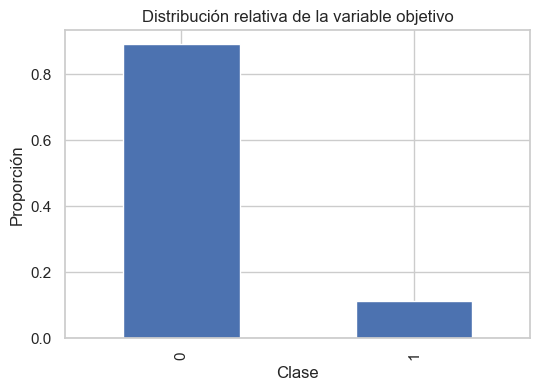

In [106]:
value_counts = df_model['readmit_30'].value_counts()
proportions = df_model['readmit_30'].value_counts(normalize=True)

plt.figure(figsize=(6,4))
proportions.plot(kind='bar')
plt.title("Distribución relativa de la variable objetivo")
plt.xlabel("Clase")
plt.ylabel("Proporción")
plt.show()

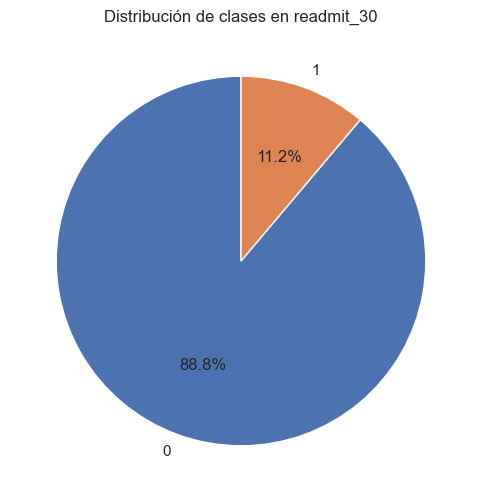

In [107]:
plt.figure(figsize=(6,6))
value_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Distribución de clases en readmit_30")
plt.ylabel("")
plt.show()

## Análisis del desbalanceo de clases

La variable objetivo presenta un claro desbalanceo entre clases, donde la clase mayoritaria corresponde a los pacientes que no presentan reingreso hospitalario en los 30 días posteriores al alta.

Este desbalanceo es un aspecto crítico del problema, ya que puede inducir a los modelos de clasificación a favorecer la predicción de la clase mayoritaria, reduciendo su capacidad para identificar correctamente los casos de reingreso (clase minoritaria).

En este contexto, será necesario considerar técnicas específicas en fases posteriores del análisis que permitan mitigar este efecto, tales como la ponderación de clases o técnicas de remuestreo, con el objetivo de mejorar la sensibilidad del modelo hacia la clase minoritaria.

## Tratamiento del desbalanceo de clases y decisión metodológica

El análisis exploratorio de la variable objetivo (`readmit_30`) ha evidenciado un claro desbalanceo entre clases, con aproximadamente un 89% de casos correspondientes a pacientes sin reingreso en los 30 días posteriores al alta y un 11% de casos positivos de reingreso.

Este desequilibrio es un fenómeno habitual en problemas de predicción clínica, donde los eventos de interés suelen ser minoritarios, pero de alta relevancia asistencial. En este contexto, el desbalanceo de clases puede afectar de forma significativa al aprendizaje de los modelos de clasificación, favoreciendo la predicción de la clase mayoritaria y reduciendo la sensibilidad hacia la clase minoritaria, que en este caso representa el evento clínicamente relevante (reingreso hospitalario).

Ante este escenario, existen diversas estrategias para mitigar el impacto del desbalanceo, entre las que destacan técnicas de remuestreo (oversampling como SMOTE o undersampling) y métodos basados en ponderación de clases (`class_weight`).

En este trabajo se ha optado por priorizar el uso de ponderación de clases en los algoritmos de aprendizaje automático, en lugar de técnicas de generación de muestras sintéticas. Esta decisión se fundamenta en varios aspectos metodológicos:

En primer lugar, las técnicas de sobremuestreo como SMOTE generan observaciones sintéticas a partir de combinaciones de vecinos en el espacio de características, lo que puede resultar problemático en datos clínicos, ya que existe el riesgo de crear perfiles de pacientes artificiales que no reflejen necesariamente la realidad clínica subyacente.

En segundo lugar, el uso de ponderación de clases permite ajustar el proceso de aprendizaje sin modificar la distribución original de los datos, preservando la integridad del conjunto de entrenamiento y evitando la introducción de sesgos derivados de la generación de datos artificiales.

Finalmente, esta aproximación es ampliamente utilizada en la literatura científica en el ámbito sanitario, especialmente en problemas de predicción de eventos clínicos raros, donde se prioriza la preservación de la estructura original del dataset y la interpretabilidad de los modelos frente a técnicas más agresivas de balanceo.

Por tanto, se ha decidido no aplicar técnicas de remuestreo en esta fase del análisis, reservando el tratamiento del desbalanceo para la etapa de modelado mediante el uso de `class_weight` en los algoritmos de clasificación.

## Exportación del dataset

Una vez completadas las fases de limpieza, transformación de variables, feature engineering y codificación de variables categóricas, se procede a la división del conjunto de datos en entrenamiento y test.

Esta división se realiza en esta fase del pipeline con el objetivo de evitar cualquier tipo de fuga de información (data leakage) durante el proceso de modelado, garantizando que las transformaciones aplicadas han sido definidas únicamente a partir del conjunto de entrenamiento.

De este modo, se generan tres conjuntos de datos:

- Conjunto de entrenamiento (`train`)
- Conjunto de test (`test`)
- Dataset completo preprocesado (`full`), utilizado como referencia o para análisis adicionales

Esta separación permite asegurar la reproducibilidad del experimento y facilita la fase posterior de modelado y evaluación.

In [114]:
train_df = X_train.copy()
train_df['readmit_30'] = y_train

test_df = X_test.copy()
test_df['readmit_30'] = y_test

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

train_df.to_csv(output_dir / "train_preprocessed.csv", index=False)
test_df.to_csv(output_dir / "test_preprocessed.csv", index=False)
df_model.to_csv(output_dir / "full_preprocessed.csv", index=False)

print("Exportación completada:")
print("- train_preprocessed.csv")
print("- test_preprocessed.csv")
print("- full_preprocessed.csv")

Exportación completada:
- train_preprocessed.csv
- test_preprocessed.csv
- full_preprocessed.csv
